# 1. BUSINESS UNDERSTANDING

This project reproduces the experiments from the RLT (Reinforcement Learning Trees) research article using ten UCI datasets.  
The goal is to evaluate whether RLT performs better than standard machine-learning models (Random Forests, Gradient Boosting, SVM, LASSO, etc.) when the data becomes high-dimensional and noisy.

Each dataset is transformed by:

- Sampling 150 training observations
- Expanding the dataset to p = 500 features by adding noise
- Comparing model performance under the same conditions

The motivation is to understand if RLT offers higher accuracy, better variable selection, and greater robustness for real-world prediction tasks.

---

# BUSINESS OBJECTIVES (BO)

- **BO1** — Improve prediction accuracy in noisy, high-dimensional data  
- **BO2** — Identify the important variables and reduce noise influence  
- **BO3** — Ensure the model is robust across multiple real-world datasets

---

# DATA SCIENCE OBJECTIVES (DSO) 

- **DSO1** — Evaluate model performance after expanding each dataset to 500 features  
  *(using RMSE/Accuracy on repeated experiments)*

- **DSO2** — Measure variable importance and the model’s ability to isolate strong features  
  *(using RLT VI, permutation importance, etc.)*

- **DSO3** — Compare stability and generalization across all 10 UCI datasets  
  *(using standardized preprocessing and repeated trials)*


# 2. DATA UNDERSTANDING


## Dataset Details

| Dataset | Type | Instances | Original Features | Target Variable |
|---------|------|-----------|-------------------|-----------------|
| **Boston Housing** | Regression | 506 | 13 | Median house price |
| **Parkinson** | Regression | 5,875 | 20 | UPDRS score |
| **Sonar** | Classification | 208 | 60 | Mine vs. Rock |
| **White Wine** | Regression | 4,898 | 11 | Wine quality score |
| **Red Wine** | Regression | 1,599 | 11 | Wine quality score |
| **Parkinson Oxford** | Classification | 195 | 22 | Disease vs. Healthy |
| **Ozone** | Classification | 2,536 | 73 | Ozone level |
| **Concrete** | Regression | 1,030 | 9 | Concrete compressive strength |
| **Breast Cancer** | Classification | 569 | 30 | Malignant vs. Benign |
| **Auto MPG** | Regression | 398 | 8 | Miles per gallon |

---

In [1]:
# =====================================================
# CHARGEMENT 
# =====================================================
import pandas as pd
import numpy as np
import requests
from io import StringIO
from sklearn.datasets import fetch_openml

all_dataframes = {}
print("Chargement des 10 datasets UCI \n")

# --------------------------------------------------
# 1. Concrete Strength
# --------------------------------------------------
print("Loading concrete ... ", end="")
df = pd.read_excel("https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls")
all_dataframes["concrete"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 2. Boston Housing
# --------------------------------------------------
print("Loading boston ... ", end="")
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")
all_dataframes["boston"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 3. Wine Quality Red
# --------------------------------------------------
print("Loading wine_red ... ", end="")
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=";")
all_dataframes["wine_red"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 4. Wine Quality White
# --------------------------------------------------
print("Loading wine_white ... ", end="")
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", sep=";")
all_dataframes["wine_white"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 5. Parkinson Oxford
# --------------------------------------------------
print("Loading parkinson_oxford ... ", end="")
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data")
all_dataframes["parkinson_oxford"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 6. Parkinson UPDRS (telemonitoring)
# --------------------------------------------------
print("Loading parkinson_ml ... ", end="")
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data")
all_dataframes["parkinson_ml"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 7. Breast Cancer Wisconsin (Diagnostic)
# --------------------------------------------------
print("Loading breast_cancer ... ", end="")
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data", header=None)
all_dataframes["breast_cancer"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 8. Sonar
# --------------------------------------------------
print("Loading sonar ... ", end="")
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data", header=None)
all_dataframes["sonar"] = df
print(f"Success: {df.shape}")

# --------------------------------------------------
# 9. Auto MPG 
# --------------------------------------------------
print("Loading autompg ... ", end="")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original"
df_auto = pd.read_fwf(url, header=None, na_values="?")
df_auto = df_auto.iloc[:, :8]  # on garde que les 8 colonnes numériques
df_auto.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
df_auto = df_auto.dropna().reset_index(drop=True)  # supprime les 6 lignes avec ?
all_dataframes["autompg"] = df_auto
print(f"Success: {df_auto.shape}")

# -------------------------------------------------
# 10. Ozone Level Detection 
# --------------------------------------------------
print("Loading ozone ... ", end="")
try:
    # Méthode principale : OpenML (toujours à jour, propre)
    ozone = fetch_openml(data_id=1487, as_frame=True, parser='auto')
    df_ozone = ozone.frame.copy()
    df_ozone.columns = [f'T{i+1}' for i in range(72)] + ['Class']
    df_ozone['Class'] = df_ozone['Class'].astype(int)
except Exception as e_openml:
    print(f"\nOpenML échoué ({e_openml}), on passe au backup fiable...")
    # Backup ultra-stable (GitHub officiel du dataset)
    url_backup = "https://raw.githubusercontent.com/datasets/ozone-level-detection/master/data/onehr.data.gz"
    df_ozone = pd.read_csv(url_backup, compression='gzip', header=None, na_values='?')
    df_ozone.columns = [f'T{i+1}' for i in range(72)] + ['Class']

all_dataframes["ozone"] = df_ozone
print(f"Success: {df_ozone.shape}")  

# --------------------------------------------------
# Export vers variables globales 
# --------------------------------------------------
for name, df in all_dataframes.items():
    globals()[f"df_{name}"] = df

print("\nTOUS LES 10 DATASETS SONT CHARGÉS CORRECTEMENT !")
print("Formes finales :")
for name, df in all_dataframes.items():
    print(f"  df_{name:<15} → {df.shape}")

Chargement des 10 datasets UCI 

Loading concrete ... Success: (1030, 9)
Loading boston ... Success: (506, 14)
Loading wine_red ... Success: (1599, 12)
Loading wine_white ... Success: (4898, 12)
Loading parkinson_oxford ... Success: (195, 24)
Loading parkinson_ml ... Success: (5875, 22)
Loading breast_cancer ... Success: (569, 32)
Loading sonar ... Success: (208, 61)
Loading autompg ... Success: (392, 8)
Loading ozone ... Success: (2534, 73)

TOUS LES 10 DATASETS SONT CHARGÉS CORRECTEMENT !
Formes finales :
  df_concrete        → (1030, 9)
  df_boston          → (506, 14)
  df_wine_red        → (1599, 12)
  df_wine_white      → (4898, 12)
  df_parkinson_oxford → (195, 24)
  df_parkinson_ml    → (5875, 22)
  df_breast_cancer   → (569, 32)
  df_sonar           → (208, 61)
  df_autompg         → (392, 8)
  df_ozone           → (2534, 73)


In [2]:
# =====================================================
#   DATA EXPLORATION 
# =====================================================

for name, df in all_dataframes.items():
    print("=" * 80)
    print(f"- DATASET: {name.upper()}")
    print("=" * 80)

    # Shape
    print(f"\n - Shape: {df.shape}")

    # Columns
    print("\n - Columns:")
    print(df.columns.tolist())

    # Data types
    print("\n - Data types:")
    print(df.dtypes)

    # Missing values
    print("\n - Missing values:")
    print(df.isnull().sum())

    # First 5 rows
    print("\n - First 5 rows:")
    display(df.head())

    # Basic statistics (numeric only)
    print("\n - Basic statistics:")
    display(df.describe())

    print("\n\n")


- DATASET: CONCRETE

 - Shape: (1030, 9)

 - Columns:
['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']

 - Data types:
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                           

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



 - Basic statistics:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225





- DATASET: BOSTON

 - Shape: (506, 14)

 - Columns:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

 - Data types:
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

 - Missing values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

 - First 5 rows:


...

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000





- DATASET: OZONE

 - Shape: (2534, 73)

 - Columns:
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27', 'T28', 'T29', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T36', 'T37', 'T38', 'T39', 'T40', 'T41', 'T42', 'T43', 'T44', 'T45', 'T46', 'T47', 'T48', 'T49', 'T50', 'T51', 'T52', 'T53', 'T54', 'T55', 'T56', 'T57', 'T58', 'T59', 'T60', 'T61', 'T62', 'T63', 'T64', 'T65', 'T66', 'T67', 'T68', 'T69', 'T70', 'T71', 'T72', 'Class']

 - Data types:
T1       float64
T2       float64
T3       float64
T4       float64
T5       float64
          ...   
T69      float64
T70      float64
T71      float64
T72      float64
Class      int32
Length: 73, dtype: object

 - Missing values:
T1       0
T2       0
T3       0
T4       0
T5       0
        ..
T69      0
T70      0
T71      0
T72      0
Class    0
Length: 73, dtype: int64

 - First 5 rows:


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T64,T65,T66,T67,T68,T69,T70,T71,T72,Class
0,0.8,1.8,2.4,2.1,2.0,2.1,1.5,1.7,1.9,2.3,...,0.150000,10.670000,-1.560000,5795.000000,-12.100000,17.900000,10330.000000,-55.000000,0.00,1
1,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,3.4,...,0.480000,8.390000,3.840000,5805.000000,14.050000,29.000000,10275.000000,-55.000000,0.00,1
2,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,2.5,...,0.600000,6.940000,9.800000,5790.000000,17.900000,41.300000,10235.000000,-40.000000,0.00,1
3,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,3.1,...,0.490000,8.730000,10.540000,5775.000000,31.150000,51.700000,10195.000000,-40.000000,2.08,1
4,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,1.4,...,0.304716,9.872418,0.830116,5818.821222,10.511051,37.388335,10164.198442,-0.119949,0.58,1



 - Basic statistics:


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T64,T65,T66,T67,T68,T69,T70,T71,T72,Class
count,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,...,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000,2534.000000
mean,1.640179,1.586351,1.545580,1.526405,1.522624,1.542417,1.637896,2.047127,2.539037,2.847708,...,0.304716,9.872418,0.830116,5818.821222,10.511051,37.388335,10164.198442,-0.119949,0.372026,1.063141
std,1.194568,1.191320,1.165651,1.133908,1.127523,1.102557,1.092811,1.092315,1.115448,1.150067,...,0.242858,9.127381,7.043762,77.410110,20.154266,10.949074,51.428116,34.693349,1.317438,0.243265
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.100000,...,0.010000,-14.920000,-25.990000,5480.000000,-56.700000,-10.100000,9975.000000,-135.000000,0.000000,1.000000
25%,0.800000,0.700000,0.700000,0.700000,0.700000,0.700000,0.800000,1.300000,1.800000,2.100000,...,0.100000,3.130000,-3.340000,5771.250000,-2.437500,33.200000,10130.000000,-20.000000,0.000000,1.000000
50%,1.600000,1.500000,1.400000,1.400000,1.400000,1.400000,1.600000,2.047127,2.539037,2.847708,...,0.250000,9.872418,0.830116,5825.000000,13.000000,40.500000,10160.000000,-0.119949,0.000000,1.000000
75%,2.200000,2.100000,2.100000,2.075000,2.000000,2.000000,2.100000,2.600000,3.200000,3.500000,...,0.460000,16.097500,4.380000,5880.000000,27.737500,44.950000,10190.000000,15.000000,0.050000,1.000000
max,7.500000,7.700000,7.100000,7.300000,7.200000,7.400000,7.400000,7.500000,9.200000,8.500000,...,1.000000,42.360000,30.420000,5965.000000,42.050000,59.150000,10350.000000,140.000000,20.650000,2.000000



=== CONCRETE DATASET ===


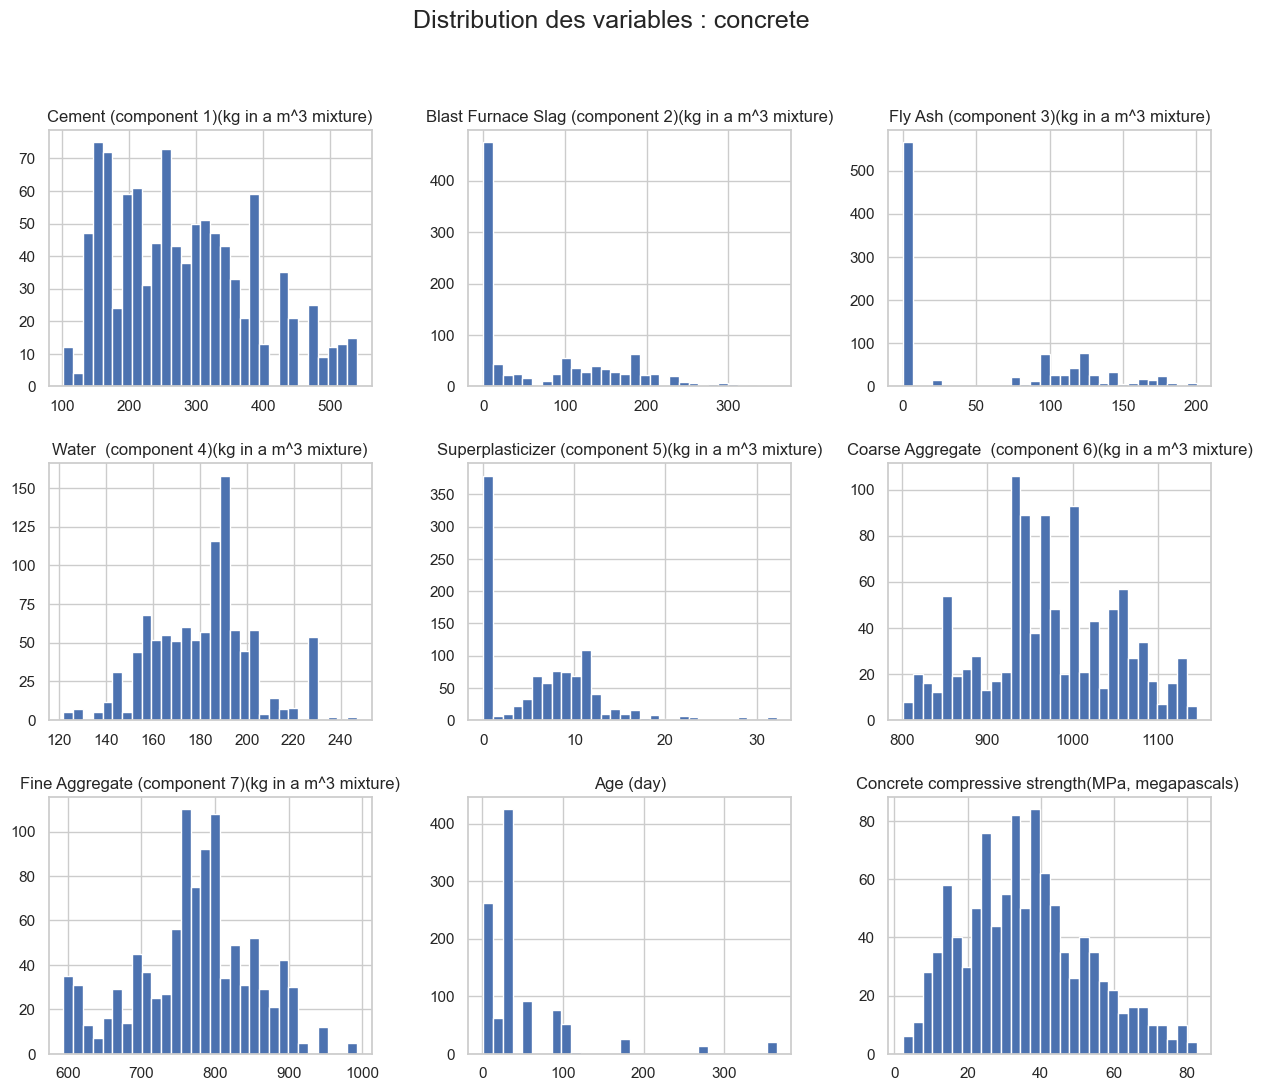

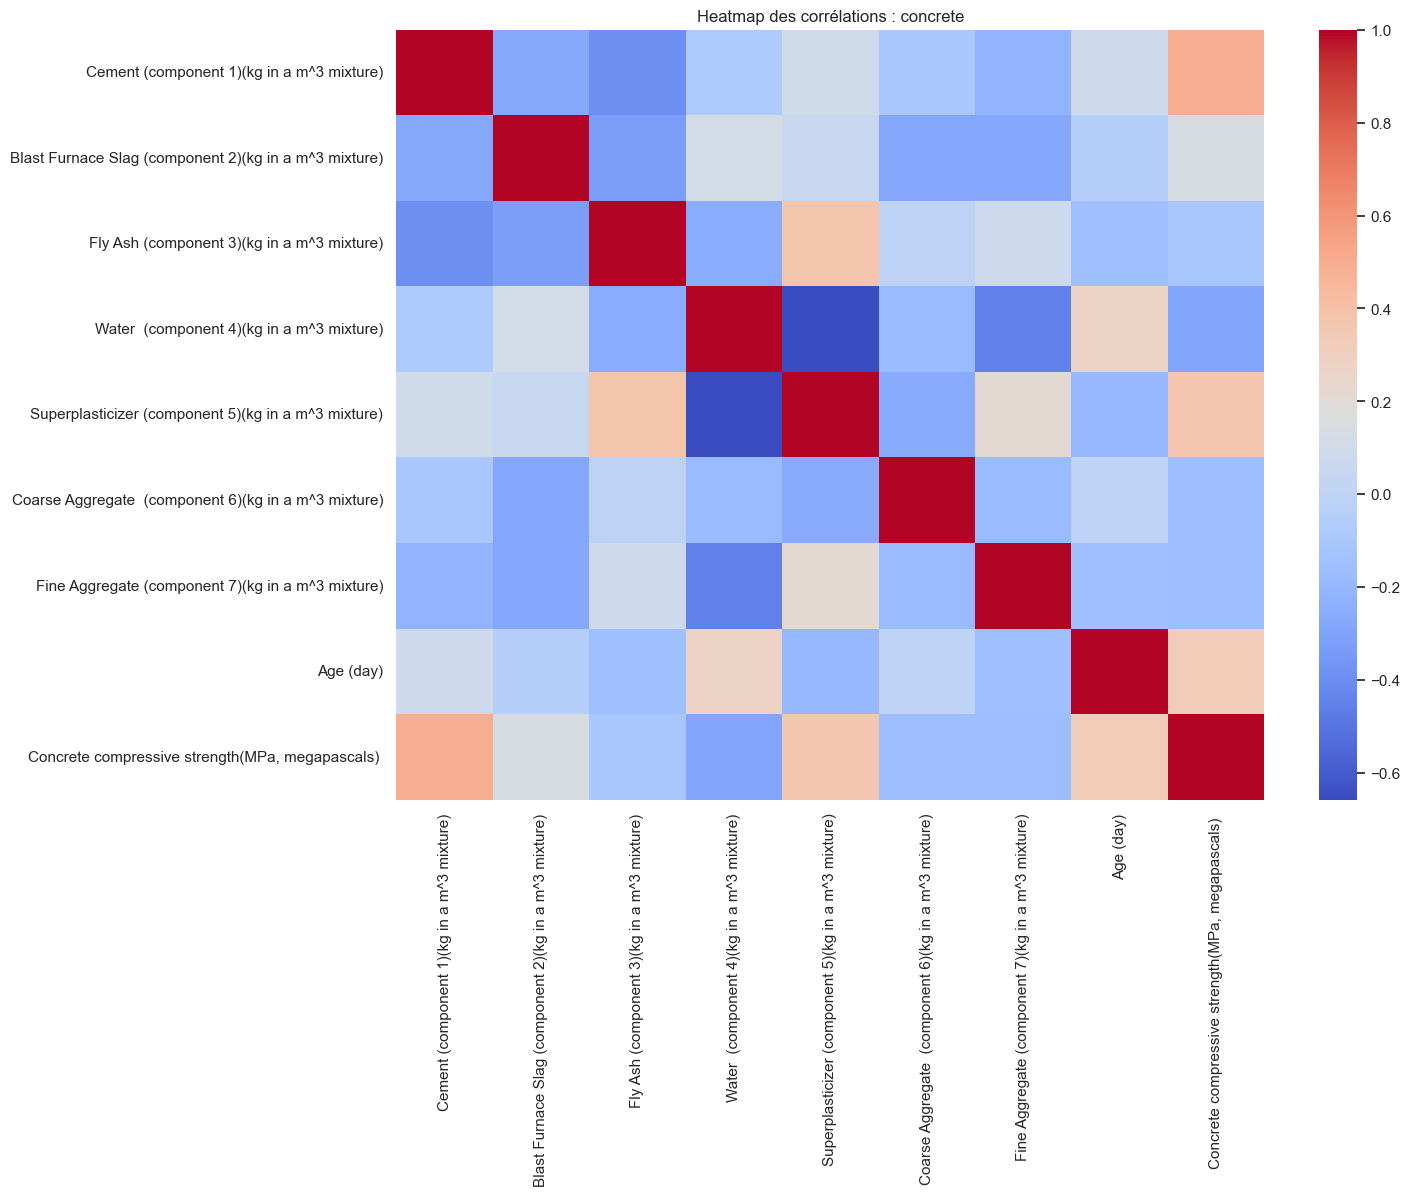

 Pairplot ignoré pour concrete (target manquante ou non spécifiée).

=== BOSTON DATASET ===


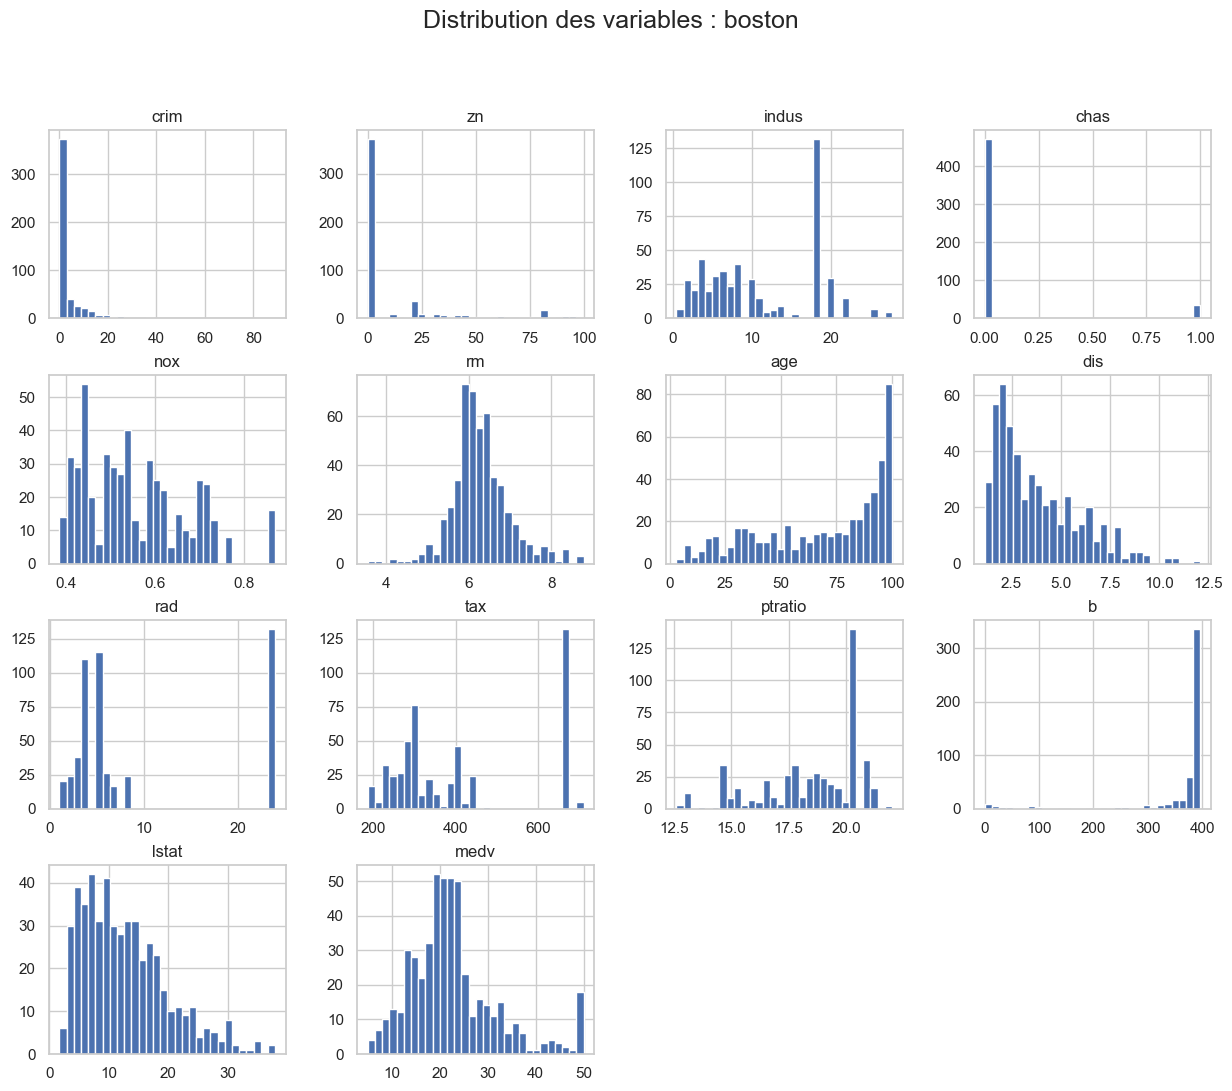

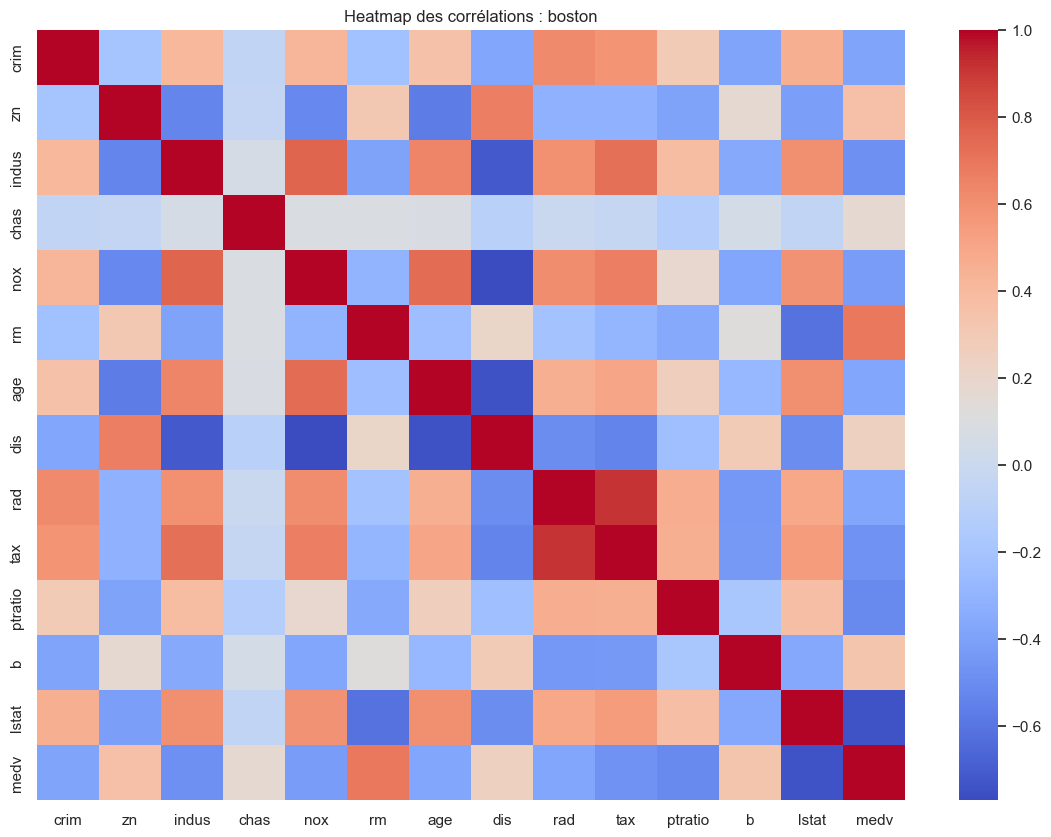

 Pairplot ignoré pour boston (target manquante ou non spécifiée).

=== WINE_RED DATASET ===


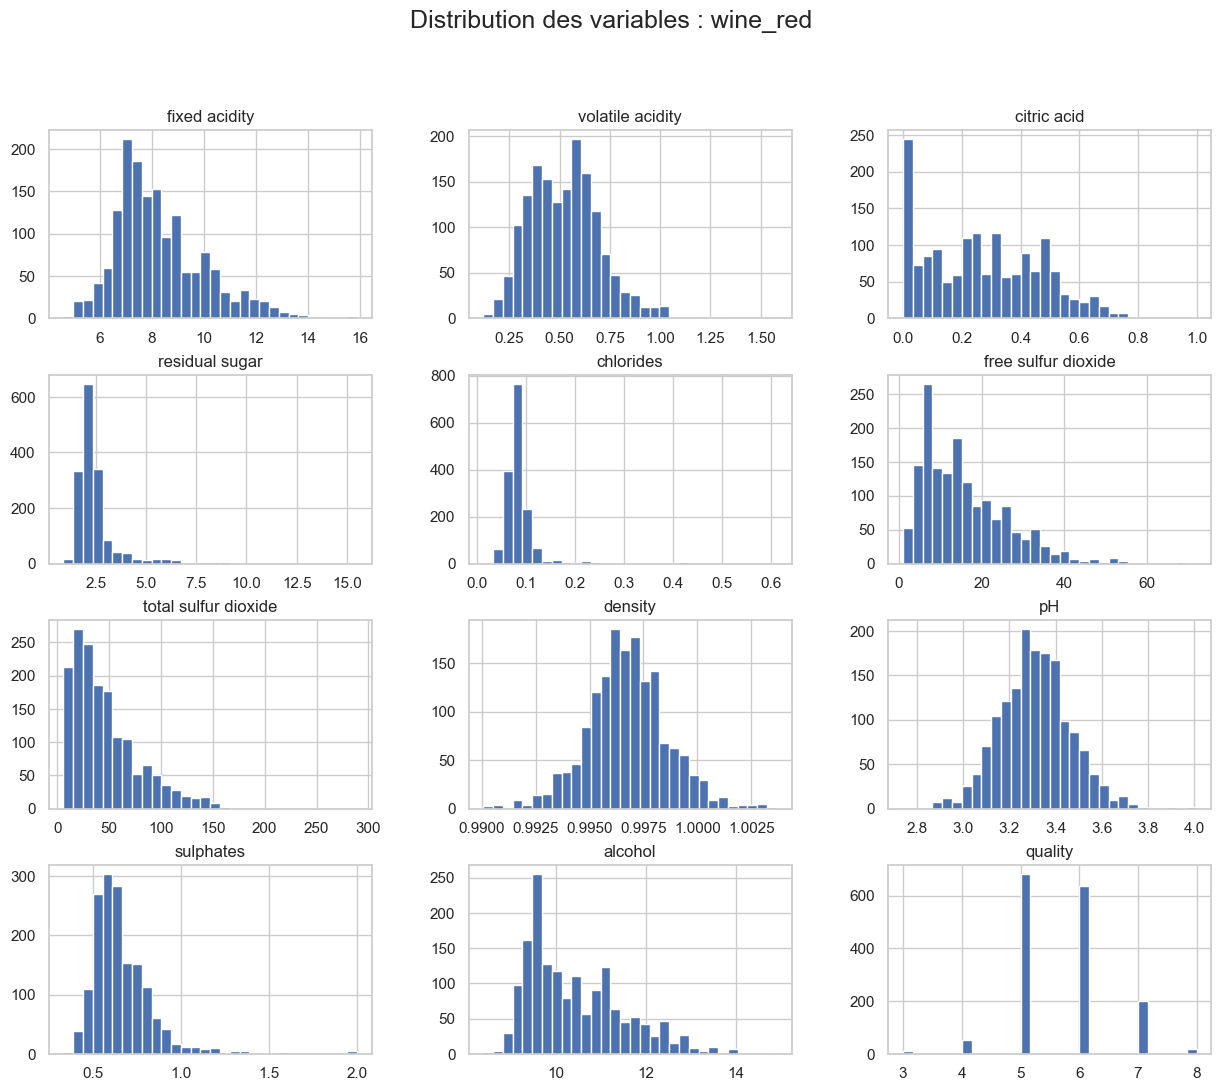

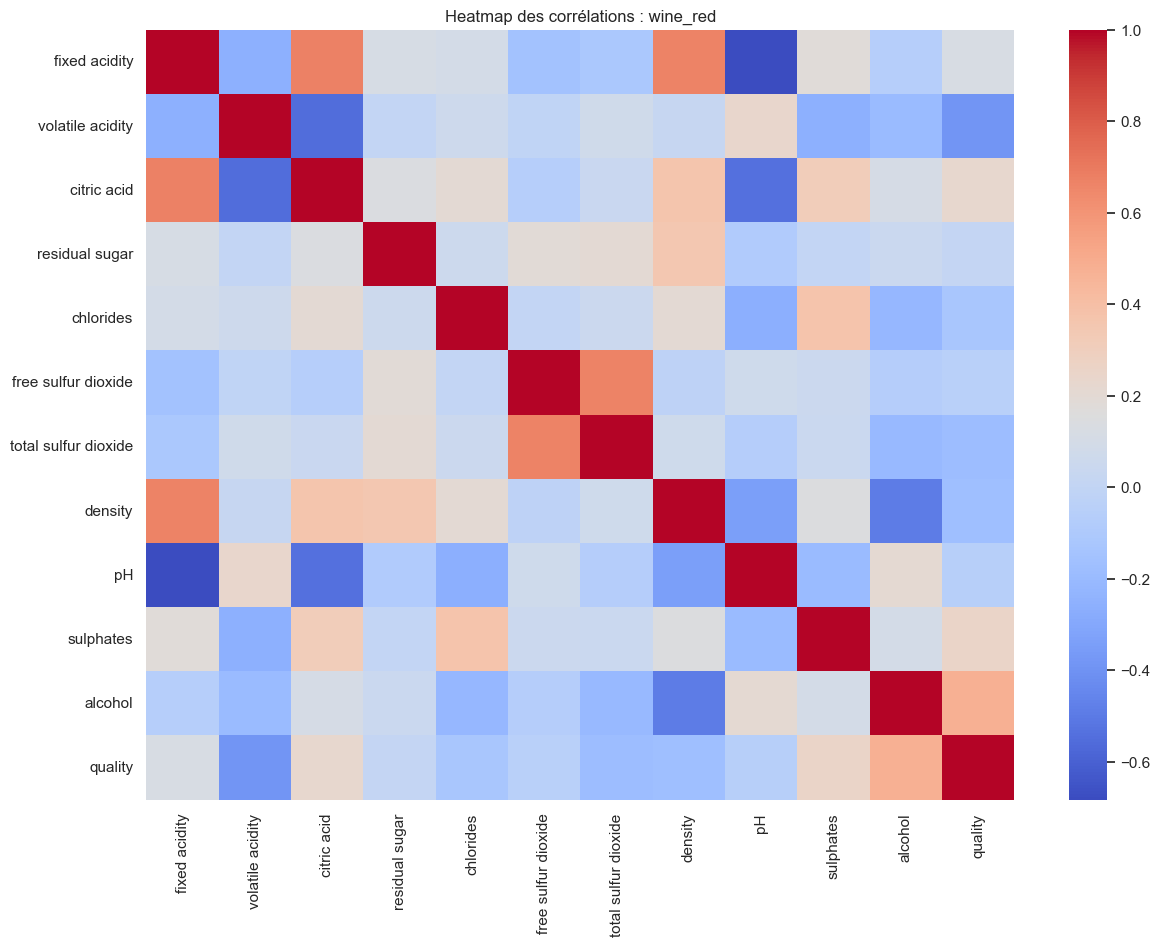

 Pairplot ignoré pour wine_red (target manquante ou non spécifiée).

=== WINE_WHITE DATASET ===


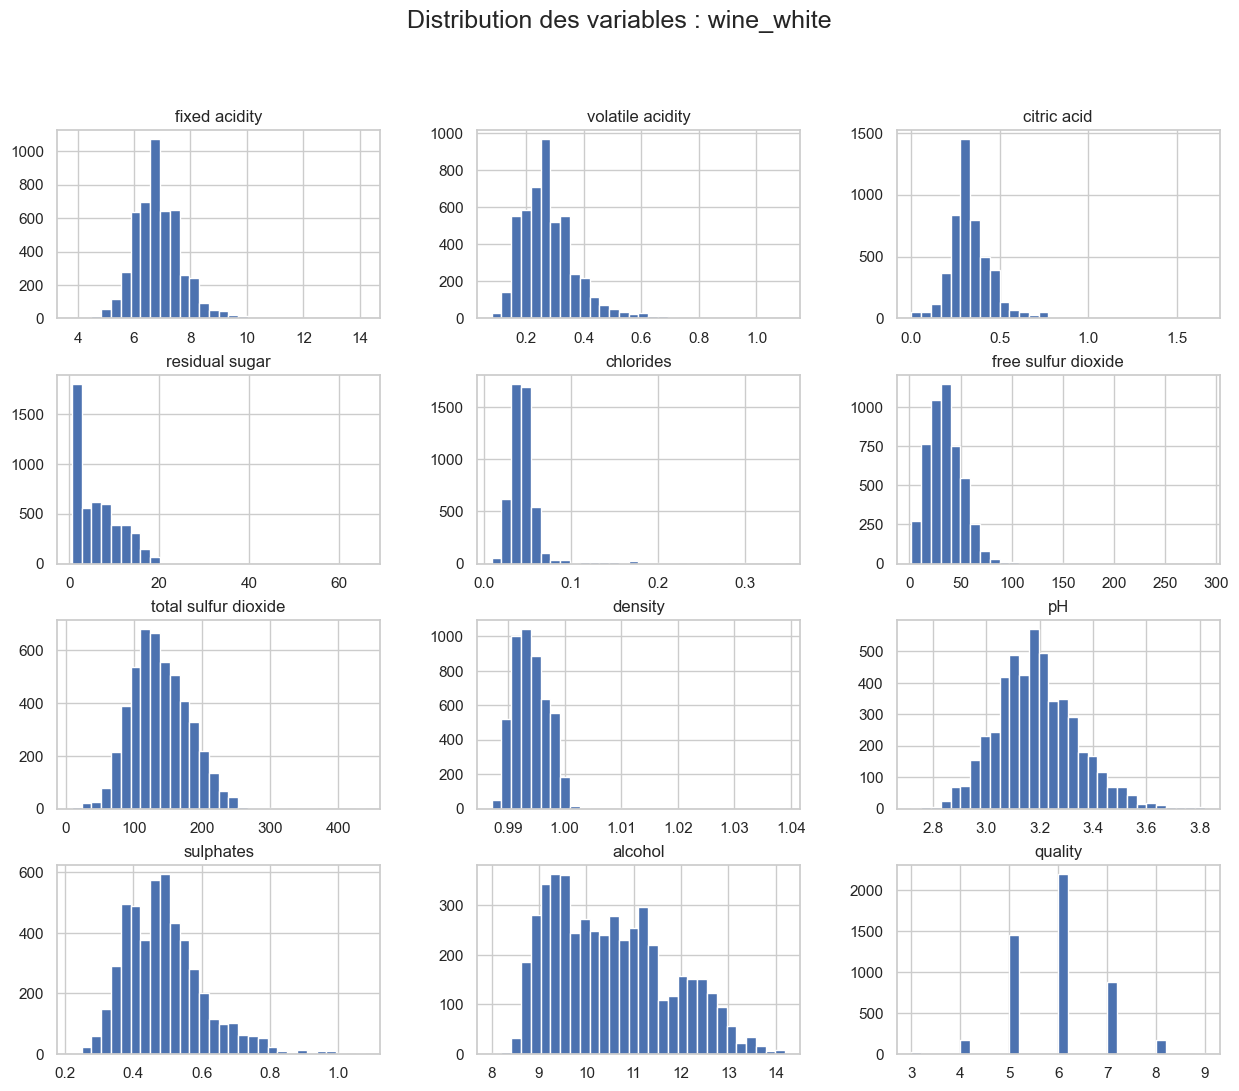

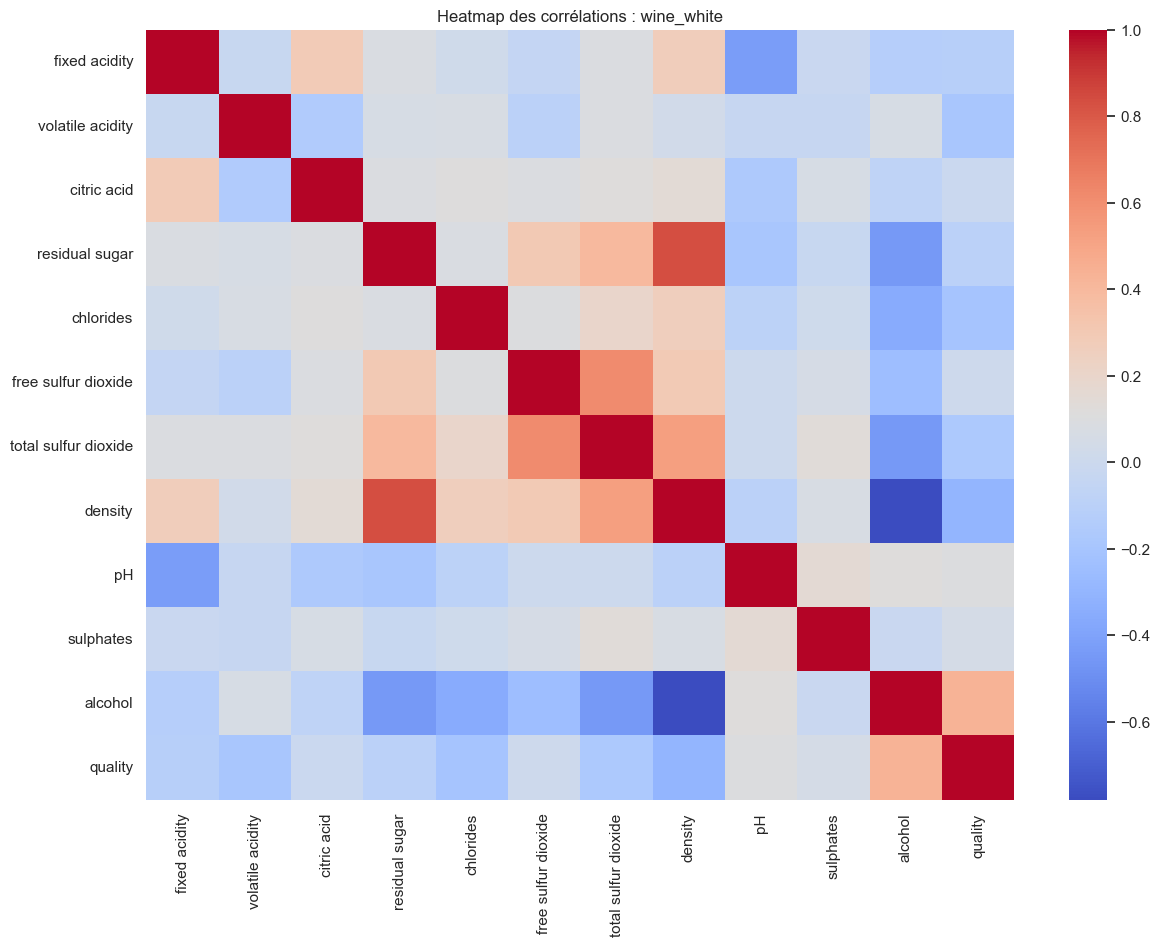

 Pairplot ignoré pour wine_white (target manquante ou non spécifiée).

=== PARKINSON_OXFORD DATASET ===


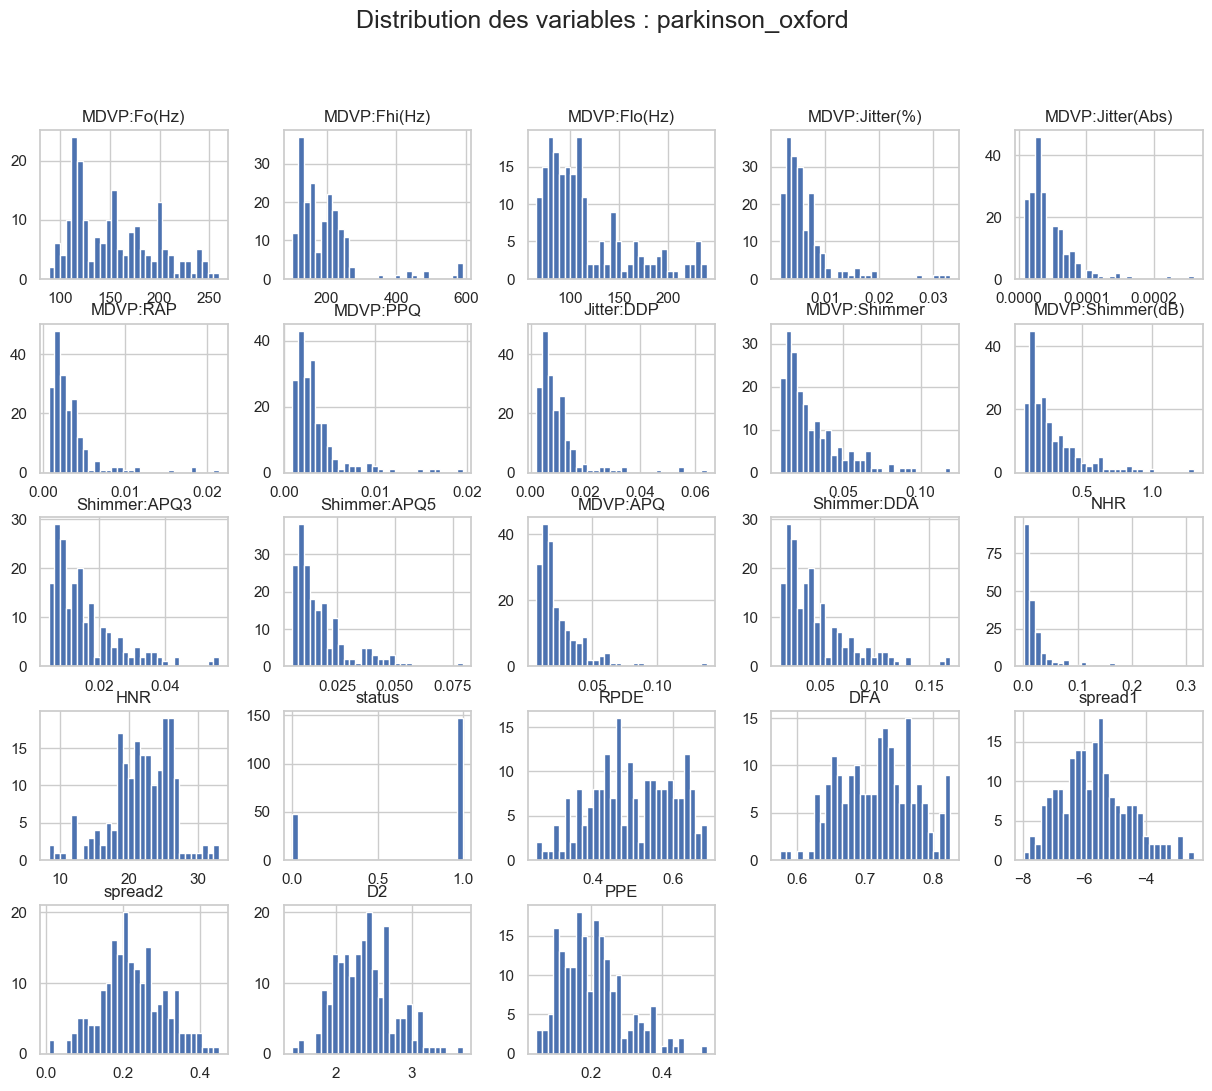

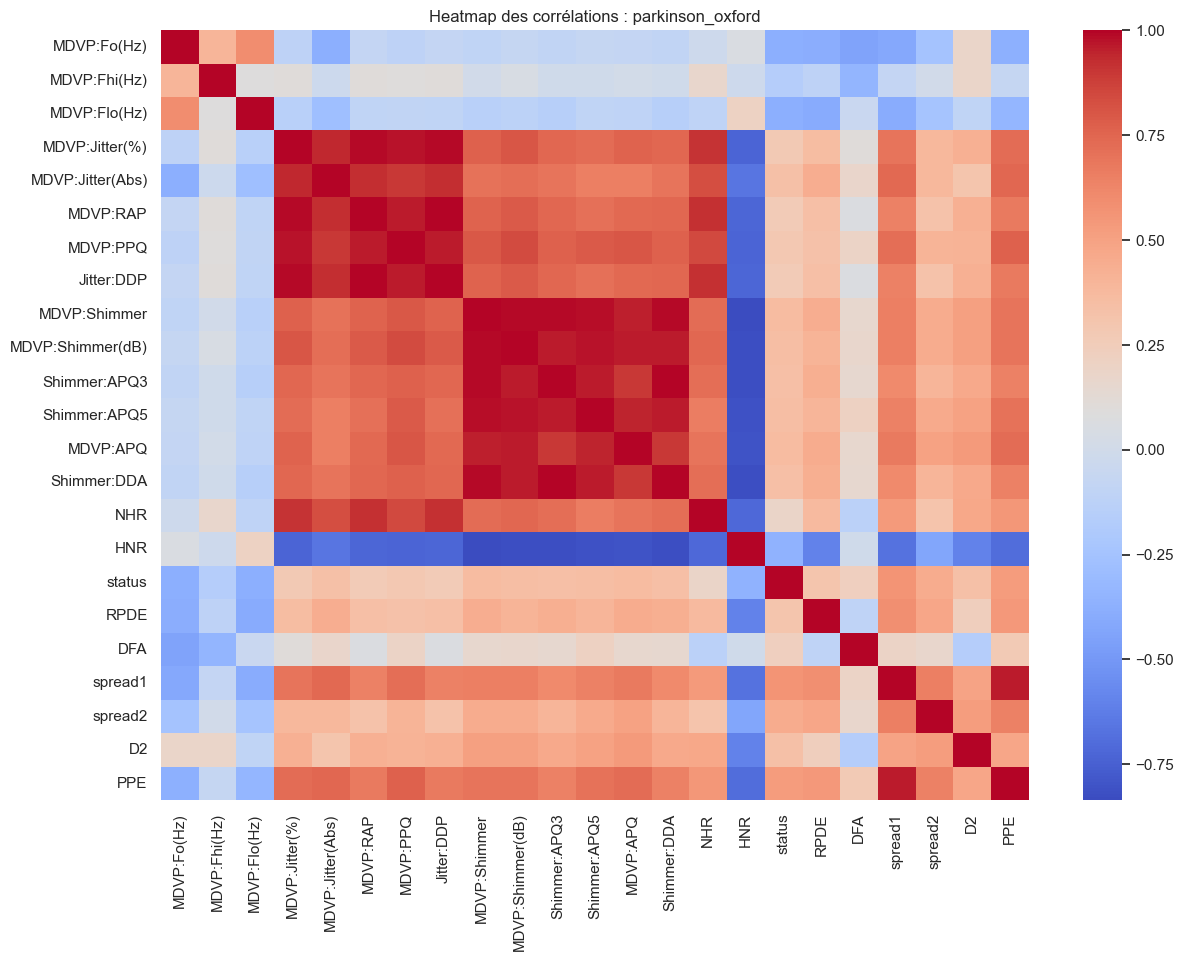

 Pairplot ignoré pour parkinson_oxford (target manquante ou non spécifiée).

=== PARKINSON_ML DATASET ===


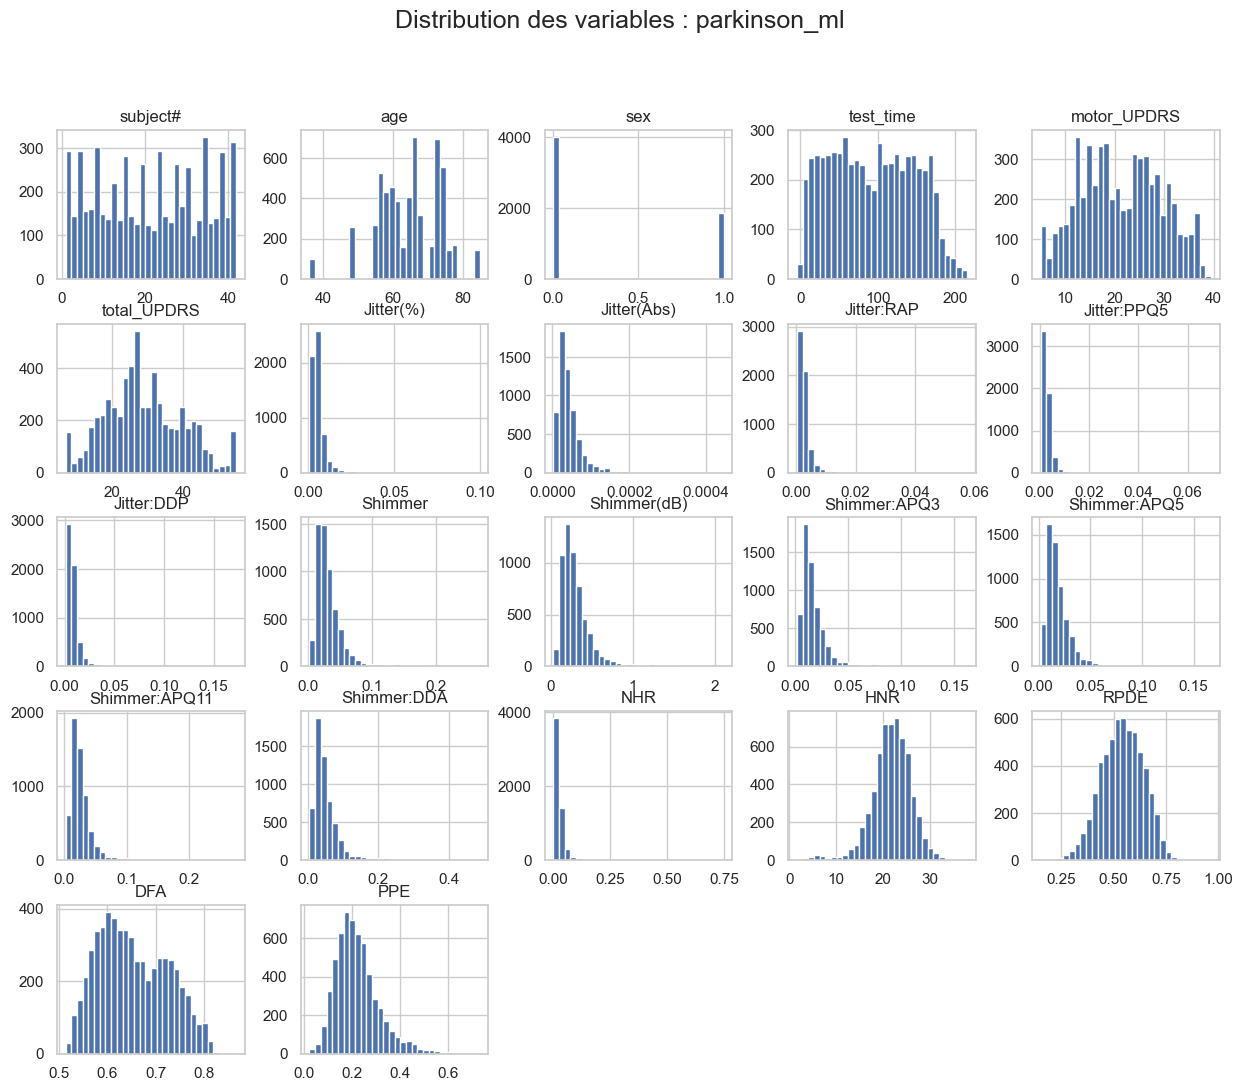

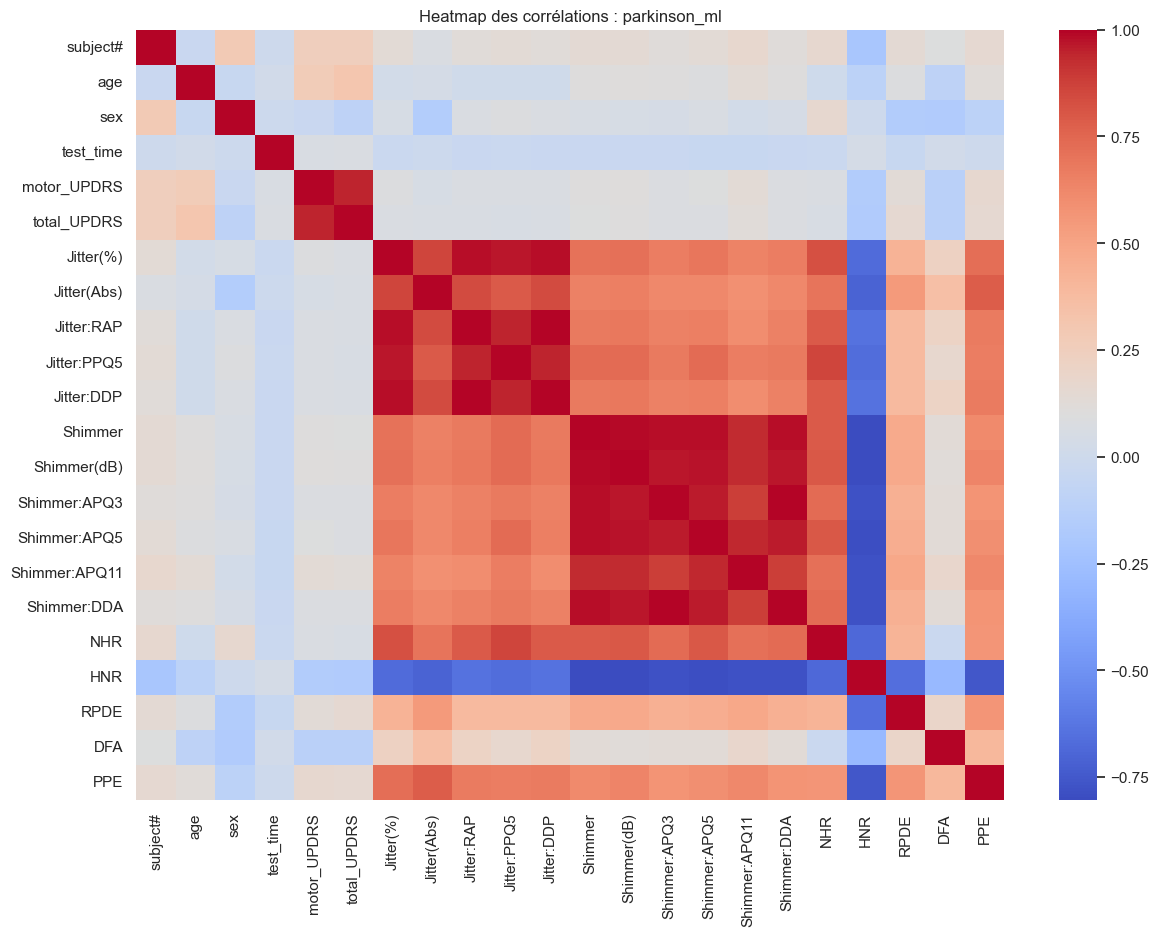

 Pairplot ignoré pour parkinson_ml (target manquante ou non spécifiée).

=== BREAST_CANCER DATASET ===


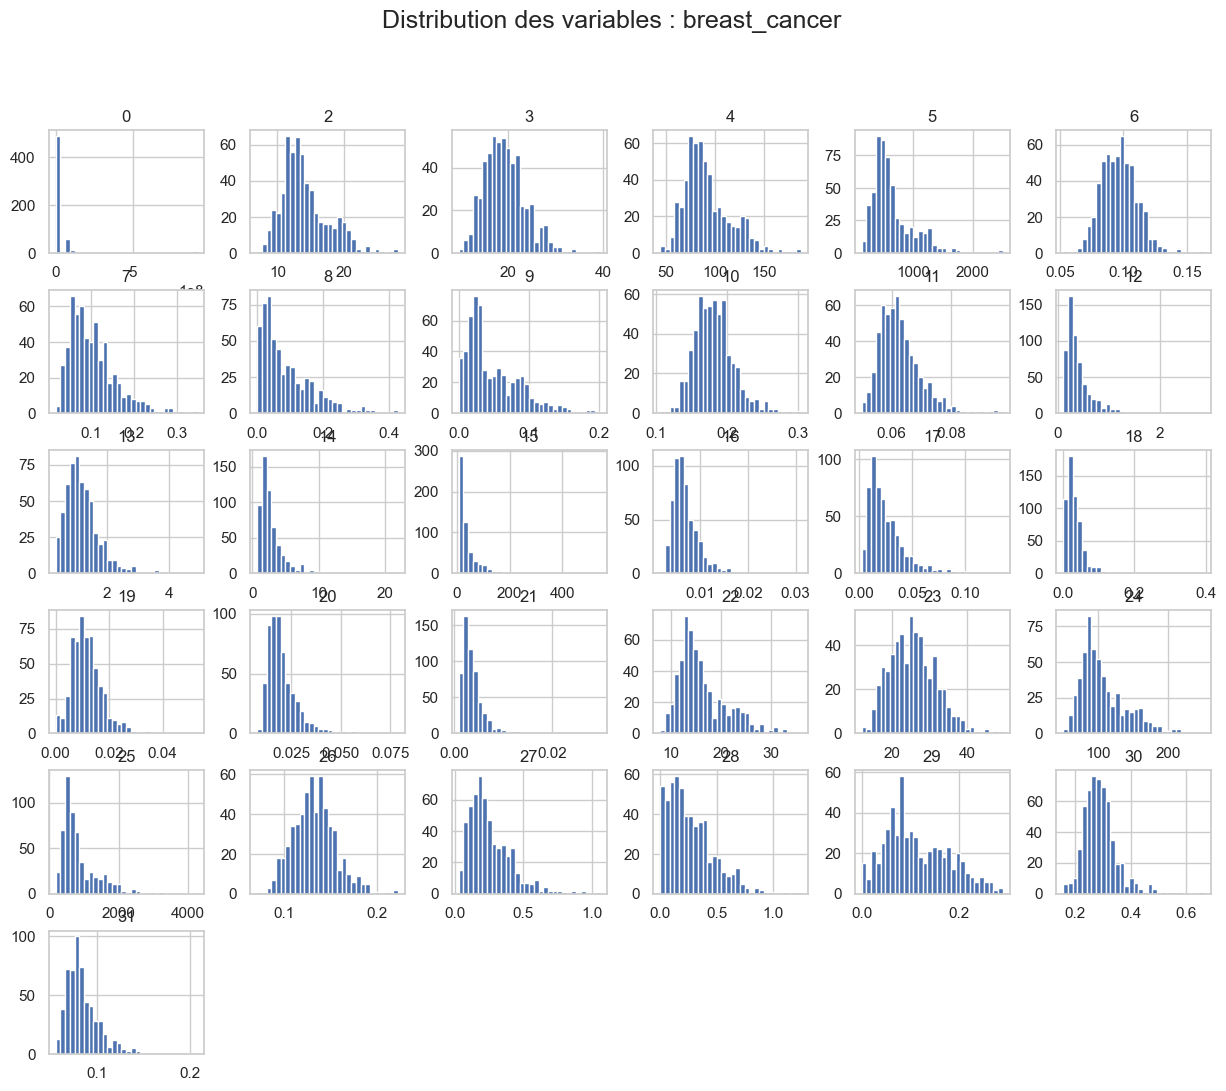

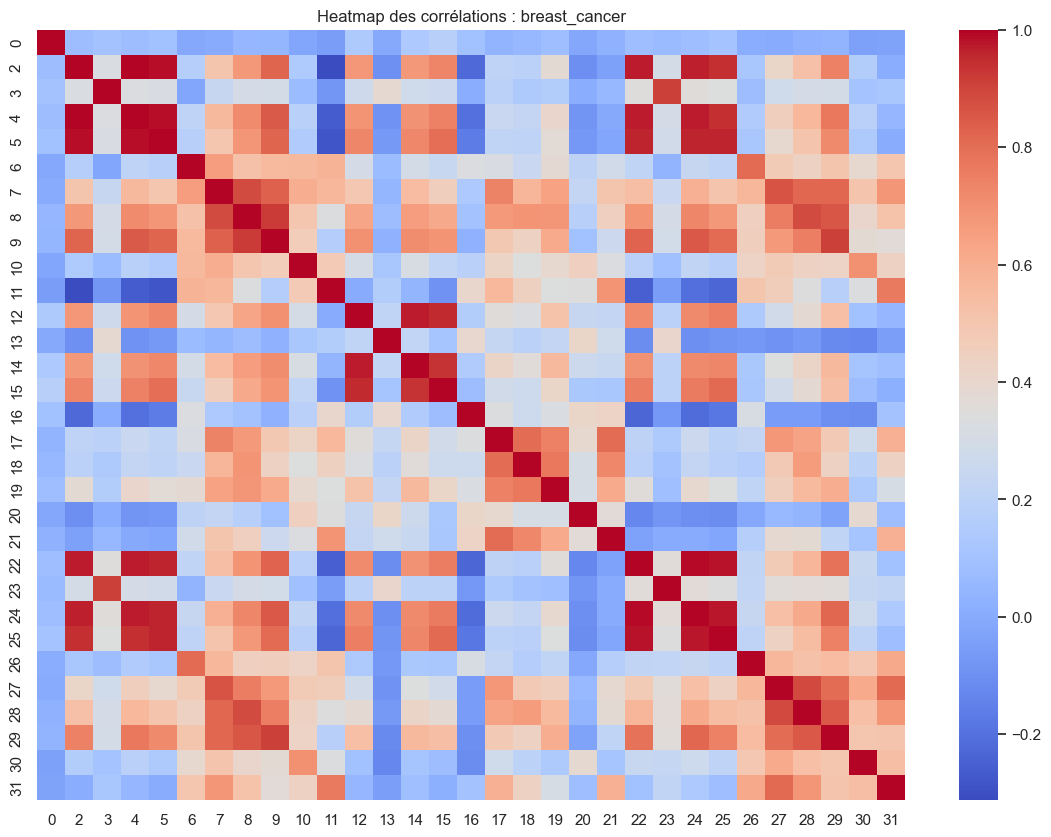

 Pairplot ignoré pour breast_cancer (target manquante ou non spécifiée).

=== SONAR DATASET ===


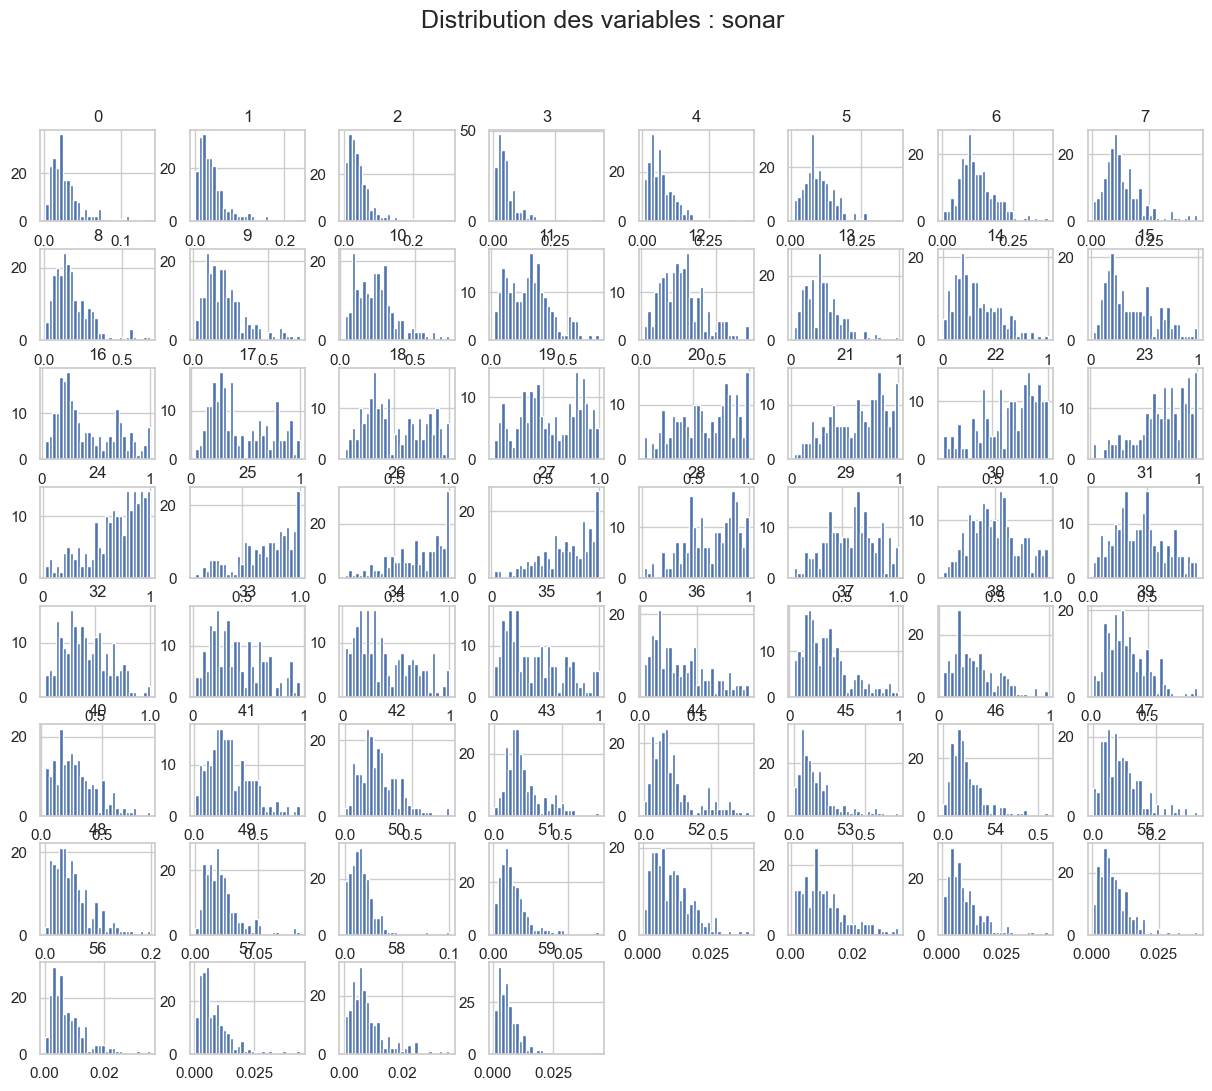

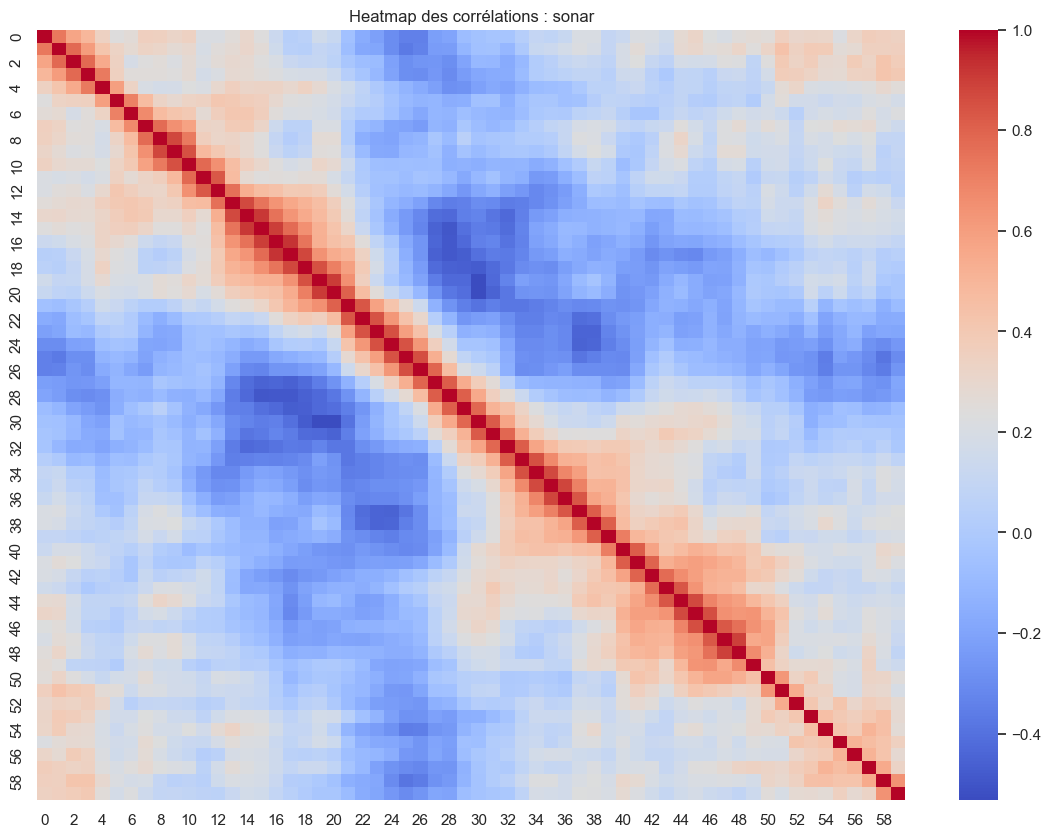

 Pairplot ignoré pour sonar (target manquante ou non spécifiée).

=== AUTOMPG DATASET ===


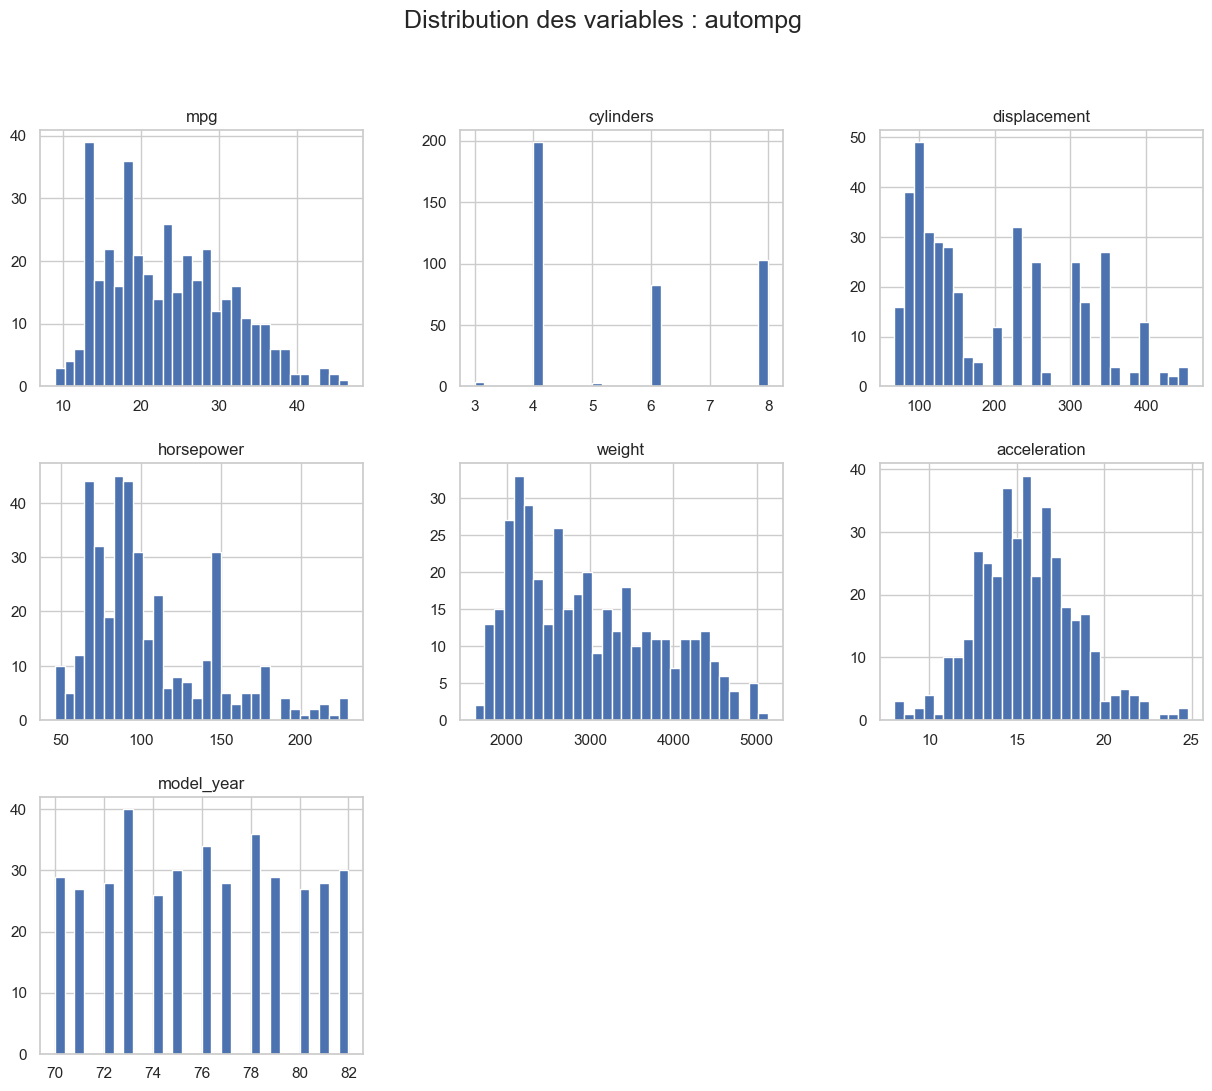

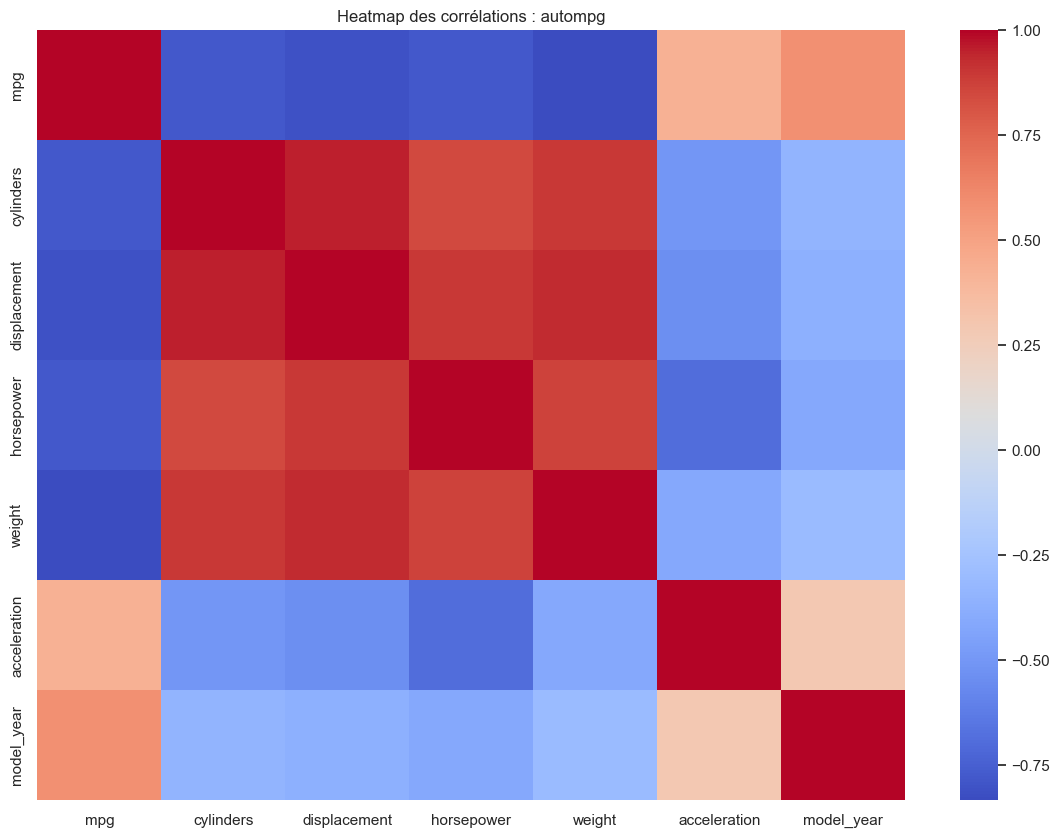

 Pairplot ignoré pour autompg (target manquante ou non spécifiée).

=== OZONE DATASET ===


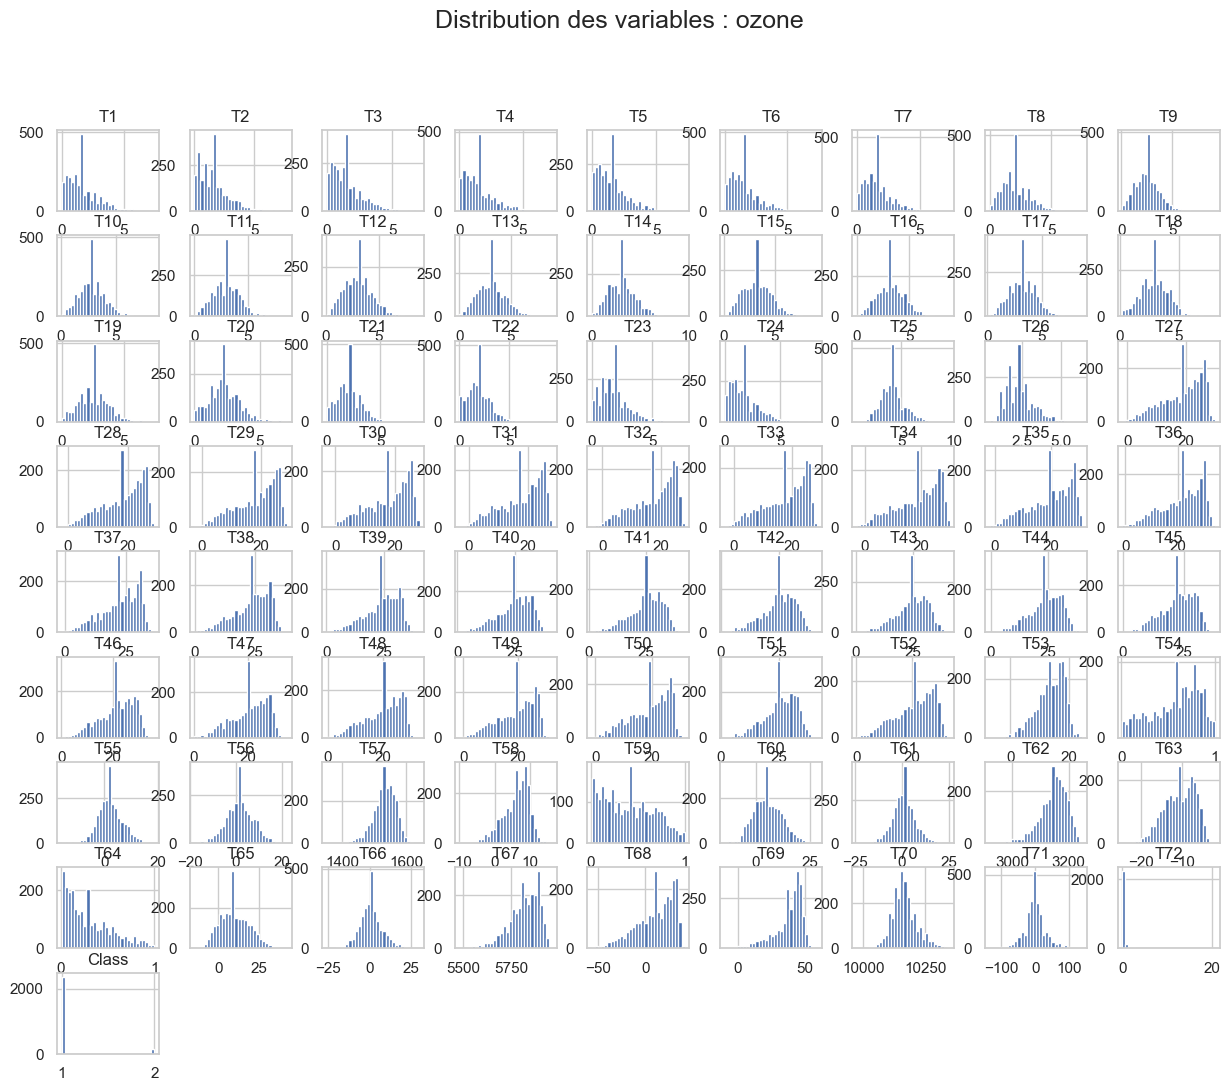

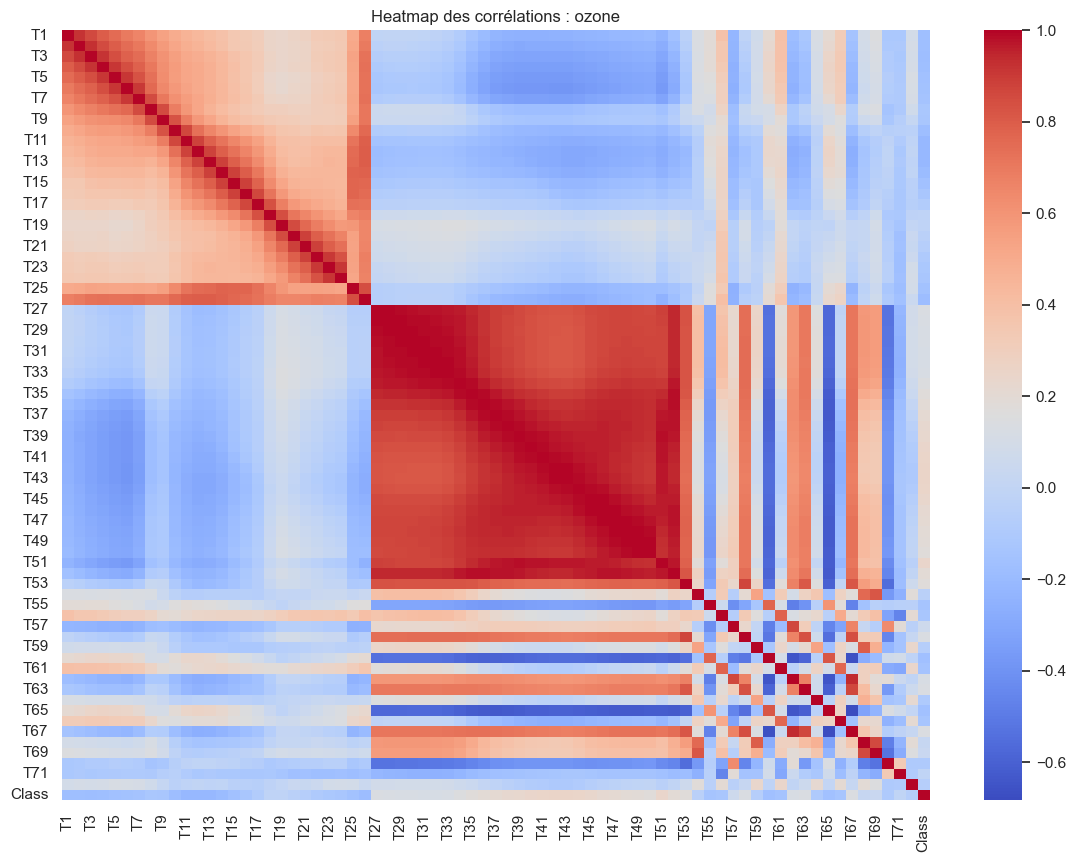

 Pairplot ignoré pour ozone (target manquante ou non spécifiée).


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="deep")

# ============================
# Visualisation Helper
# ============================
def plot_distributions(df, title):
    """Affiche les histogrammes des colonnes numériques"""
    df.hist(figsize=(15, 12), bins=30)
    plt.suptitle(f"Distribution des variables : {title}", fontsize=18)
    plt.show()

def plot_correlations(df, title):
    """Affiche la heatmap des corrélations sur les colonnes numériques uniquement"""
    numeric_df = df.select_dtypes(include='number')
    if numeric_df.shape[1] < 2:
        print(f" Pas assez de colonnes numériques pour la corrélation dans {title}")
        return
    plt.figure(figsize=(14, 10))
    sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
    plt.title(f"Heatmap des corrélations : {title}")
    plt.show()


def plot_pairplot(df, target=None, title=""):
    """Affiche un pairplot si la target existe"""
    if target and target in df.columns:
        sample = df.sample(min(300, len(df)), random_state=42)
        sns.pairplot(sample, hue=target)
        plt.suptitle(f"Pairplot : {title}", y=1.02)
        plt.show()
    else:
        print(f" Pairplot ignoré pour {title} (target manquante ou non spécifiée).")

# ============================
# Appliquer aux datasets
# ============================

targets = {
    "CONCRETE": "Concrete compressive strength(MPa, megapascals)",
    "BOSTON": "medv",   
    "WINE RED": "quality"
}

for name, df in all_dataframes.items():
    print(f"\n=== {name.upper()} DATASET ===")
    plot_distributions(df, name)
    plot_correlations(df, name)
    plot_pairplot(df, targets.get(name), name)


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class RLTPipelineOptimizedMemory:
    """
    Pipeline préparation des données.
    """
    
    def __init__(self, n_train=150, p_target=500, snr_ratio=(1, 2), random_state=42):
        self.n_train = n_train
        self.p_target = p_target
        self.signal_var, self.noise_var = snr_ratio
        self.random_state = random_state
        np.random.seed(random_state)
    
    def _extract_target_robust(self, df, target_spec):
        """Extraction robuste avec vérification."""
        # Vérifier et corriger le nom de la cible pour concrete
        if isinstance(target_spec, str):
            # Chercher la colonne (tolérance aux variations)
            possible_names = [target_spec, 
                            target_spec.lower(),
                            target_spec.replace(' ', '_'),
                            target_spec.split('(')[0].strip()]
            
            for name in possible_names:
                if name in df.columns:
                    target_name = name
                    break
            else:
                # Afficher les colonnes disponibles pour debug
                print(f"   Colonne '{target_spec}' non trouvée.")
                print(f"  Colonnes disponibles: {df.columns.tolist()[:5]}...")
                # Prendre la dernière colonne comme cible par défaut
                target_name = df.columns[-1]
                print(f"  Utilisation par défaut: {target_name}")
        else:
            target_name = df.columns[target_spec]
        
        # Séparer features et cible
        y = df[target_name].values
        X = df.drop(columns=[target_name])
        
        return X, y, target_name
    
    def _ensure_numeric(self, X_df):
        """Convertir toutes les colonnes en numérique si possible."""
        X_numeric = X_df.copy()
        
        # Convertir les colonnes non-numériques
        for col in X_numeric.columns:
            if X_numeric[col].dtype == 'object':
                try:
                    X_numeric[col] = pd.to_numeric(X_numeric[col], errors='coerce')
                except:
                    # Si échec, encoder catégoriel simple
                    X_numeric[col] = pd.factorize(X_numeric[col])[0]
        
        # Remplir les NaN restants
        X_numeric = X_numeric.fillna(X_numeric.median())
        
        return X_numeric.values.astype(np.float32)  # float32 pour économiser mémoire
    
    def _impute_missing_safe(self, X):
        """Imputation sécurisée pour différents types de données."""
        if X.dtype != np.float32 and X.dtype != np.float64:
            X = X.astype(np.float32)
        
        # Vérifier s'il y a des NaN
        if np.issubdtype(X.dtype, np.number):
            nan_mask = np.isnan(X)
            if nan_mask.any():
                col_medians = np.nanmedian(X, axis=0)
                row_idx, col_idx = np.where(nan_mask)
                X[row_idx, col_idx] = col_medians[col_idx]
        
        return X
    
    def prepare_single_dataset(self, df, dataset_name, target_spec, is_classification, save_individual=True):
        """
        Préparation d'un dataset avec sauvegarde immédiate pour économiser mémoire.
        """
        print(f"\n Préparation: {dataset_name}")
        
        try:
            # Vérification taille
            if len(df) <= self.n_train:
                print(f"  Trop petit: {len(df)} échantillons")
                return None
            
            # Étape 1: Extraction robuste
            X_df, y, target_name = self._extract_target_robust(df, target_spec)
            print(f"  ✓ Extraction: {X_df.shape[1]} features, {len(y)} échantillons")
            
            # Étape 2: Conversion en numérique
            X = self._ensure_numeric(X_df)
            
            # Étape 3: Imputation
            X = self._impute_missing_safe(X)
            
            # Étape 4: Standardisation
            X_std = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
            print(f"  ✓ Standardisation terminée")
            
            # Étape 5: Augmentation vers p=500
            n_original = X_std.shape[1]
            if n_original < self.p_target:
                n_extra = self.p_target - n_original
                
                # Calcul des variances
                orig_variances = np.var(X_std, axis=0)
                orig_variances[orig_variances == 0] = 1.0
                
                # Indices aléatoires pour l'augmentation
                orig_indices = np.random.choice(n_original, size=n_extra, replace=True)
                noise_scales = np.sqrt(self.noise_var * orig_variances[orig_indices] / self.signal_var)
                
                # Génération du bruit
                noise = np.random.normal(0, 1, size=(len(X_std), n_extra))
                noise = noise * noise_scales
                
                # Features supplémentaires
                extra_features = X_std[:, orig_indices] + noise
                
                # Combinaison
                X_aug = np.hstack([X_std, extra_features]).astype(np.float32)
            else:
                X_aug = X_std[:, :self.p_target].astype(np.float32)
            
            print(f"  ✓ Augmentation: {X_aug.shape[1]} features")
            
            # Étape 6: Encodage cible
            if is_classification:
                y_encoded = pd.factorize(y)[0].astype(np.int32)
            else:
                y_encoded = y.astype(np.float32)
            
            # Étape 7: Split
            train_idx = np.random.choice(len(X_aug), self.n_train, replace=False)
            test_idx = np.setdiff1d(np.arange(len(X_aug)), train_idx)
            
            X_train = X_aug[train_idx]
            y_train = y_encoded[train_idx]
            X_test = X_aug[test_idx]
            y_test = y_encoded[test_idx]
            
            # Validation
            assert X_train.shape[1] == self.p_target
            assert len(y_train) == self.n_train
            
            print(f"  ✓ Split: Train={X_train.shape}, Test={X_test.shape}")
            print(f"  ✓ Type: {'Classification' if is_classification else 'Regression'}")
            
            # Sauvegarde immédiate pour libérer mémoire
            if save_individual:
                self._save_dataset_individual(dataset_name, X_train, y_train, X_test, y_test, is_classification)
            
            # Retourner seulement les métadonnées pour économiser mémoire
            return {
                'dataset_name': dataset_name,
                'train_shape': X_train.shape,
                'test_shape': X_test.shape,
                'is_classification': is_classification,
                'saved_path': f"{dataset_name}_rlt.npz"
            }
            
        except Exception as e:
            print(f"   Erreur: {str(e)[:100]}...")
            return None
    
    def _save_dataset_individual(self, name, X_train, y_train, X_test, y_test, is_classif):
        """Sauvegarde individuelle pour économiser mémoire."""
        save_dict = {
            'X_train': X_train.astype(np.float32),
            'y_train': y_train,
            'X_test': X_test.astype(np.float32),
            'y_test': y_test,
            'is_classification': is_classif
        }
        
        np.savez_compressed(f"{name}_rlt.npz", **save_dict)
        print(f"   Sauvegardé: {name}_rlt.npz")


DATASET_CONFIGS = {
    'concrete': {
        'df': df_concrete,
        'target': 'strength',  # Nom simplifié
        'classification': False
    },
    'boston': {
        'df': df_boston, 
        'target': 'medv',
        'classification': False
    },
    'wine_red': {
        'df': df_wine_red,
        'target': 'quality',
        'classification': False
    },
    'wine_white': {
        'df': df_wine_white,
        'target': 'quality',
        'classification': False
    },
    'parkinson_oxford': {
        'df': df_parkinson_oxford,
        'target': 'status',
        'classification': True
    },
    'parkinson_ml': {
        'df': df_parkinson_ml,
        'target': 'total_UPDRS',
        'classification': False
    },
    'breast_cancer': {
        'df': df_breast_cancer,
        'target': 1,  # Colonne 1 = diagnostic
        'classification': True
    },
    'sonar': {
        'df': df_sonar,
        'target': 60,  # Dernière colonne
        'classification': True
    },
    'autompg': {
        'df': df_autompg,
        'target': 'mpg',
        'classification': False
    },
    'ozone': {
        'df': df_ozone,
        'target': 'Class',
        'classification': True
    }
}

# ============================================================================
# EXÉCUTION SÉQUENTIELLE POUR ÉCONOMISER MÉMOIRE
# ============================================================================
def execute_with_memory_management():
    """Exécution optimisée pour mémoire limitée."""
    
    print("="*70)
    print("PIPELINE OPTIMISÉ AVEC GESTION MÉMOIRE")
    print("="*70)
    
    pipeline = RLTPipelineOptimizedMemory(
        n_train=150,
        p_target=500,
        snr_ratio=(1, 2),
        random_state=42
    )
    
    results = []
    
    # Traiter un dataset à la fois
    for name, config in DATASET_CONFIGS.items():
        print(f"\n{'='*50}")
        print(f"Traitement: {name}")
        print(f"{'='*50}")
        
        result = pipeline.prepare_single_dataset(
            df=config['df'],
            dataset_name=name,
            target_spec=config['target'],
            is_classification=config['classification'],
            save_individual=True
        )
        
        if result:
            results.append(result)
            print(f" {name}: RÉUSSI")
        else:
            print(f" {name}: ÉCHEC")
        
        # Libérer mémoire explicitement
        import gc
        gc.collect()
    
    # Rapport final
    print("\n" + "="*70)
    print("RAPPORT FINAL")
    print("="*70)
    
    if results:
        df_report = pd.DataFrame(results)
        print(df_report[['dataset_name', 'train_shape', 'test_shape', 'is_classification']].to_string(index=False))
    else:
        print("Aucun dataset préparé avec succès.")
    
    print(f"\n Datasets réussis: {len(results)}/10")
    
    return results

# ============================================================================
# CHARGER UN DATASET PRÉPARÉ
# ============================================================================
def load_prepared_dataset(dataset_name):
    """Charger un dataset préparé depuis le disque."""
    try:
        data = np.load(f"{dataset_name}_rlt.npz", allow_pickle=True)
        
        return {
            'X_train': data['X_train'],
            'y_train': data['y_train'],
            'X_test': data['X_test'],
            'y_test': data['y_test'],
            'is_classification': data['is_classification'].item() if data['is_classification'].dtype == bool else bool(data['is_classification'])
        }
    except Exception as e:
        print(f"Erreur chargement {dataset_name}: {e}")
        return None

# ============================================================================
# EXÉCUTER LE PIPELINE
# ============================================================================
if __name__ == "__main__":
    # Exécuter le pipeline
    results = execute_with_memory_management()
    
    # Exemple: charger un dataset
    print("\n" + "="*70)
    print("CHARGEMENT DES DATASETS PRÉPARÉS")
    print("="*70)
    
    if results:
        # Charger le premier dataset réussi
        first_dataset = results[0]['dataset_name']
        data = load_prepared_dataset(first_dataset)
        
        if data:
            print(f"\n✓ Dataset '{first_dataset}' chargé:")
            print(f"  X_train: {data['X_train'].shape}")
            print(f"  y_train: {data['y_train'].shape}")
            print(f"  X_test:  {data['X_test'].shape}")
            print(f"  y_test:  {data['y_test'].shape}")
            print(f"  Type:    {'Classification' if data['is_classification'] else 'Regression'}")

PIPELINE OPTIMISÉ AVEC GESTION MÉMOIRE

Traitement: concrete

 Préparation: concrete
   Colonne 'strength' non trouvée.
  Colonnes disponibles: ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)']...
  Utilisation par défaut: Concrete compressive strength(MPa, megapascals) 
  ✓ Extraction: 8 features, 1030 échantillons
  ✓ Standardisation terminée
  ✓ Augmentation: 500 features
  ✓ Split: Train=(150, 500), Test=(880, 500)
  ✓ Type: Regression
   Sauvegardé: concrete_rlt.npz
 concrete: RÉUSSI

Traitement: boston

 Préparation: boston
  ✓ Extraction: 13 features, 506 échantillons
  ✓ Standardisation terminée
  ✓ Augmentation: 500 features
  ✓ Split: Train=(150, 500), Test=(356, 500)
  ✓ Type: Regression
   Sauvegardé: boston_rlt.npz
 boston: RÉUSSI

Traitement: wine_red

 Préparation: wine_red
 